Importing package and data

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv("gold_data_2015_25.csv")
df

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2015-01-02,2058.199951,114.080002,159.119995,15.110000,1.208941
1,2015-01-05,2020.579956,115.800003,150.320007,15.500000,1.194643
2,2015-01-06,2002.609985,117.120003,144.399994,15.830000,1.193902
3,2015-01-07,2025.900024,116.430000,146.960007,15.850000,1.187536
4,2015-01-08,2062.139893,115.940002,148.399994,15.640000,1.183600
...,...,...,...,...,...,...
2661,2025-08-08,6389.450195,313.049988,73.300003,34.880001,1.167665
2662,2025-08-11,6373.450195,308.549988,73.800003,34.180000,1.164795
2663,2025-08-12,6445.759766,308.269989,72.949997,34.410000,1.161845
2664,2025-08-13,6466.580078,309.209991,72.459999,35.000000,1.167706


Data Inspection

In [33]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2015-01-02,2058.199951,114.080002,159.119995,15.11,1.208941
1,2015-01-05,2020.579956,115.800003,150.320007,15.50,1.194643
2,2015-01-06,2002.609985,117.120003,144.399994,15.83,1.193902
3,2015-01-07,2025.900024,116.430000,146.960007,15.85,1.187536
4,2015-01-08,2062.139893,115.940002,148.399994,15.64,1.183600


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2666 non-null   str    
 1   SPX      2666 non-null   float64
 2   GLD      2666 non-null   float64
 3   USO      2666 non-null   float64
 4   SLV      2666 non-null   float64
 5   EUR/USD  2666 non-null   float64
dtypes: float64(5), str(1)
memory usage: 151.1 KB


In [35]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,3504.231271,158.601665,80.319745,19.414055,1.118508
std,1212.323340,47.245813,27.665948,4.972436,0.052239
min,1829.079956,100.500000,17.040001,11.210000,0.959619
25%,2467.489929,120.650002,67.842497,15.530000,1.083887
50%,3168.685059,154.665001,78.254997,17.415000,1.115219
75%,4373.047607,178.547501,93.279999,22.547500,1.156076
max,6468.540039,316.290009,166.559998,35.720001,1.251001


In [36]:
df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [37]:
df.duplicated().sum()

np.int64(0)

The dataset has 2,666 rows. It has no missing values and no duplicate rows.

Now, filtering and grouping

In [ ]:
average_gold_price = df["GLD"].mean()
high_goldprice_days = df[df["GLD"] > average_gold_price]
print("Avg price:", round(average_gold_price, 2))
print("Days above the average:", len(high_goldprice_days))
high_goldprice_days.head()

Avg price: 158.6
Days above the average: 1299


,Date,SPX,GLD,USO,SLV,EUR/USD,Year
1323,2020-04-09,2789.820068,158.690002,39.840000,14.34,1.086366,2020
1324,2020-04-13,2761.629883,161.410004,39.439999,14.40,1.093267,2020
1325,2020-04-14,2846.060059,162.679993,37.279999,14.65,1.092299,2020
1326,2020-04-15,2783.360107,161.850006,35.439999,14.49,1.098539,2020
1327,2020-04-16,2799.550049,161.710007,34.880001,14.51,1.090510,2020


In [39]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
yearly_summary = df.groupby("Year")["GLD"].agg(["mean", "count"]).round(2)
yearly_summary

,mean,count
Year,,
2015,111.15,252
2016,119.36,252
2017,119.71,249
2018,120.18,251
2019,131.56,251
2020,166.65,253
2021,168.31,252
2022,167.91,251
2023,180.45,250


The yearly averages show that GLD was fairly stable from 2015 through 2018 and then increased strongly, especially in 2024 and the available part of 2025. The 2025 count is lower because the dataset ends in August 2025.

Plots and visualizaation


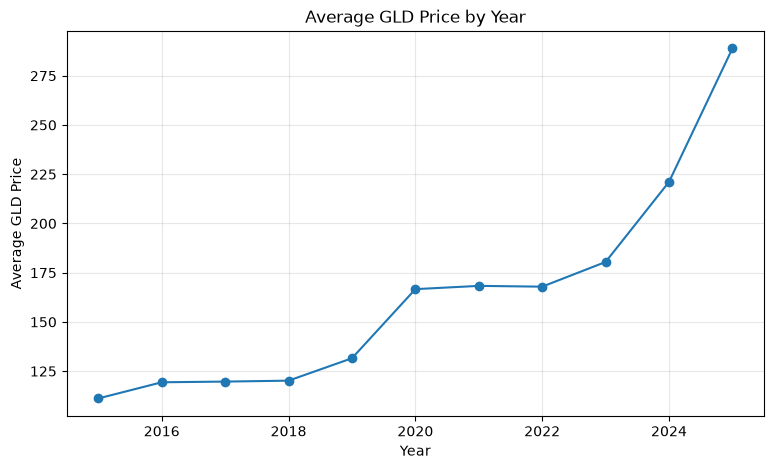

In [40]:
yearly_summary["mean"].plot(kind="line", marker="o", figsize=(9, 5))
plt.title("Average GLD Price by Year")
plt.xlabel("Year")
plt.ylabel("Average GLD Price")
plt.grid(alpha=0.3)
plt.show()

This linear regression estimates a target by finding a straight-line relationship between the inputs and output. The model inputs are SPX, USO, SLV, and EUR/USD. The output is gold price. A fixed random seed makes the 80% training and 20% testing split reproducible.

In [41]:
features = ["SPX", "USO", "SLV", "EUR/USD"]
X = df[features].to_numpy()
y = df["GLD"].to_numpy()
print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (2666, 4)
Output shape: (2666,)


In [42]:
random_generator = np.random.default_rng(42)
shuffled_rows = random_generator.permutation(len(df))
split_point = int(len(df) * 0.8)
train_rows = shuffled_rows[:split_point]
test_rows = shuffled_rows[split_point:]
X_train = X[train_rows]
X_test = X[test_rows]
y_train = y[train_rows]
y_test = y[test_rows]

In [43]:
X_train_model = np.column_stack([np.ones(len(X_train)), X_train])
coefficients = np.linalg.lstsq(X_train_model, y_train, rcond=None)[0]
X_test_model = np.column_stack([np.ones(len(X_test)), X_test])
predictions = X_test_model @ coefficients

In [44]:
mae = np.mean(np.abs(y_test - predictions))
r_squared = 1 - np.sum((y_test - predictions) ** 2) / np.sum((y_test - y_test.mean()) ** 2)
print("Mean absolute error:", round(mae, 2))
print("R-squared:", round(r_squared, 3))

Mean absolute error: 9.77
R-squared: 0.907


Gold Price prediction from 2025 to 2050

This simple linear regression uses year to extend the historical GLD trend through 2050.

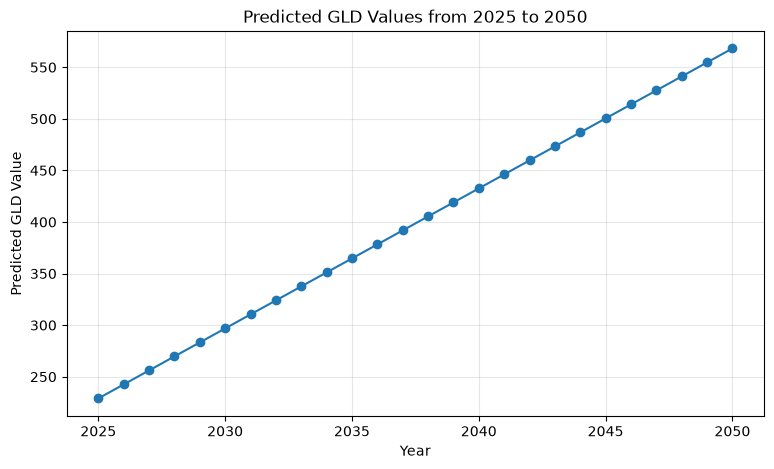

In [45]:
future_years = np.arange(2025, 2051)
trend = np.polyfit(df["Year"], df["GLD"], 1)
future_predictions = np.polyval(trend, future_years)
plt.figure(figsize=(9, 5))
plt.plot(future_years, future_predictions, marker="o")
plt.title("Predicted GLD Values from 2025 to 2050")
plt.xlabel("Year")
plt.ylabel("Predicted GLD Value")
plt.grid(alpha=0.3)
plt.show()

In [46]:
coefficient_table = pd.DataFrame({"Feature": ["Intercept"] + features, "Coefficient": coefficients})
coefficient_table

,Feature,Coefficient
0,Intercept,61.149624
1,SPX,0.016205
2,USO,-0.012224
3,SLV,5.349855
4,EUR/USD,-55.450472


Result:
The average gold price value is about 158.60, and 1,299 days are above that average. The yearly mean rises from about 111.15 in 2015 to about 288.87 in the available 2025 data. The test mean absolute error is about 9.77, and the R-squared value is about 0.907. This is a useful first experiment, but it does not prove that the input variables cause gold prices or that the model will predict future prices accurately.